# Apply the BMCD / hdeGPD pipeline to a new dataset

Run the full chain end-to-end on a new rainfall dataset:

1. **Ingest** raw daily-precipitation CSVs (or load a pre-extracted spells JSON).
2. **Build** the canonical spells JSON.
3. **Fit** dry-spell hdeGPD (PWM) and wet-spell mixture-geometric (EM).
4. **Stationarity check** (5-year rolling mean +/- std) per station, per season.
5. **Per-station diagnostic figures** Figs 2, 6-11.

All outputs are namespaced under `figures/<DATASET>/` so they don't collide with the southern-Europe outputs in `figures/figure_*/`.

All logic lives in [`article_code.run_on_new_dataset`](../run_on_new_dataset.py); this notebook is a thin shell so the script and notebook stay in lockstep.

## 1. Dataset configuration

Edit this cell only. Set **either** `CSV_DIR` (one `<station>.csv` per station with date+precip columns) **or** `SPELLS_JSON` (already-extracted spells in the canonical schema).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parents[1]))

from article_code import run_on_new_dataset as runner
from article_code.util_files import config

DATASET_NAME    = "toy"
CSV_DIR         = pathlib.Path("../../data/toy_data/toy_csv_data")
SPELLS_JSON     = None       # e.g. pathlib.Path("/path/to/spells.json")  -- mutually exclusive with CSV_DIR
DATE_COL        = "date"
PRECIP_COL      = "precip"
WET_THRESHOLD   = config.WET_DAY_THRESHOLD     # e.g. 6 (in 0.1 mm units)
START_YEAR      = config.START_YEAR            # spells starting earlier are dropped
DROP_FIRST_LAST = True                         # drop censored spells at segment edges
MIN_NUMBER_SPELL = None                        # set e.g. 365*10 to reject sparse stations

# Per-run knobs (None = process all stations, no skipping)
ONLY            = None       # e.g. ["STATION_A", "STATION_B"]
FIRST           = None       # e.g. 5
SKIP_EXISTING   = False

paths = runner.dataset_paths(DATASET_NAME)
for k, v in paths.items():
    print(f"{k:18s}: {v}")

root              : C:\Users\antoi\Desktop\code\companion_code_article
spells_json       : C:\Users\antoi\Desktop\code\companion_code_article\data\toy_data\exports_json\toy_spells.json
fit_folder        : C:\Users\antoi\Desktop\code\companion_code_article\results_fit\fit_toy
dry_fit_csv       : C:\Users\antoi\Desktop\code\companion_code_article\results_fit\fit_toy\dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv
wet_fit_csv       : C:\Users\antoi\Desktop\code\companion_code_article\results_fit\fit_toy\wet_spell_fit_mixt_geomresult_fit_parameters.csv
stationarity_dir  : C:\Users\antoi\Desktop\code\companion_code_article\figures\toy\stationnarity
figures_root      : C:\Users\antoi\Desktop\code\companion_code_article\figures\toy


## 2. Ingest -> spells JSON

If `SPELLS_JSON` is set, the file is copied into the dataset namespace and extraction is skipped. Otherwise each `<station>.csv` is read, dates parsed, and the spell extractor is run.

In [2]:
import json

if SPELLS_JSON is not None and CSV_DIR is not None:
    raise ValueError("Set exactly one of CSV_DIR or SPELLS_JSON, not both.")

paths["spells_json"].parent.mkdir(parents=True, exist_ok=True)

if SPELLS_JSON is not None:
    spells = runner.load_spells_json(SPELLS_JSON)
    with open(paths["spells_json"], "w", encoding="utf-8") as fh:
        json.dump(spells, fh, ensure_ascii=False, indent=2)
    print(f"[ingest] spells-json mode: {len(spells)} stations -> {paths['spells_json']}")
elif CSV_DIR is not None:
    d = runner.ingest_csv_dir(
        CSV_DIR,
        date_col=DATE_COL,
        precip_col=PRECIP_COL,
        wet_threshold=WET_THRESHOLD,
        drop_first_last=DROP_FIRST_LAST,
        start_year=START_YEAR,
        min_number_spells=MIN_NUMBER_SPELL,
    )
    runner.write_spells_json(d, paths["spells_json"])
    spells = runner.load_spells_json(paths["spells_json"])
    print(f"[ingest] csv-dir mode: {len(spells)} stations -> {paths['spells_json']}")
else:
    spells = runner.load_spells_json(paths["spells_json"])
    print(f"[ingest] reused existing JSON: {len(spells)} stations")

# Quick sanity peek at one station
first_station = sorted(spells.keys())[0]
print(f"\nfirst station: {first_station}")
print(f"  dry spells: {len(spells[first_station]['dry_spell']['duration_spell'])}")
print(f"  wet spells: {len(spells[first_station]['wet_spell']['duration_spell'])}")

Ingesting CSVs:   0%|          | 0/5 [00:00<?, ?it/s, value=ATHENS]

Ingesting CSVs: 100%|██████████| 5/5 [00:12<00:00,  2.53s/it, value=ROME]     

[ingest] kept 5 stations, rejected 0
[ingest] csv-dir mode: 5 stations -> C:\Users\antoi\Desktop\code\companion_code_article\data\toy_data\exports_json\toy_spells.json

first station: ATHENS
  dry spells: 2949
  wet spells: 2950


## 3. Fit dry hdeGPD + wet mixture-geometric

Writes two CSVs into `results_fit/fit_<DATASET>/`. Skip this cell if you've already fit and just want to re-plot.

In [3]:
import pandas as pd

dry_csv, wet_csv = runner.fit_dry_and_wet(paths["spells_json"], paths["fit_folder"])
df_fit_dry = pd.read_csv(dry_csv)
df_fit_wet = pd.read_csv(wet_csv)
print(f"dry-fit rows: {len(df_fit_dry)} -> {dry_csv}")
print(f"wet-fit rows: {len(df_fit_wet)} -> {wet_csv}")
df_fit_dry.head()

dry_spell:   0%|          | 0/5 [00:00<?, ?it/s]

wet_spell: 100%|██████████| 5/5 [00:18<00:00,  3.69s/it]

dry-fit rows: 25 -> C:\Users\antoi\Desktop\code\companion_code_article\results_fit\fit_toy\dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv
wet-fit rows: 25 -> C:\Users\antoi\Desktop\code\companion_code_article\results_fit\fit_toy\wet_spell_fit_mixt_geomresult_fit_parameters.csv


,data_source,f_1,kappa,sigma,xi
0,ATHENS all,0.173957,0.962570,5.654830,0.242038
1,ATHENS spring,0.140562,1.038014,6.015404,0.215881
2,ATHENS summer,0.030303,0.994426,16.598728,0.008806
3,ATHENS autumn,0.213542,0.862579,5.357273,-0.056180
4,ATHENS winter,0.205291,0.880054,5.362098,-0.012576


## 4. Stationarity check (per station)

Two PDFs per station (dry, wet) with 5-year rolling mean +/- std per season.

In [4]:
stationarity_results = runner.run_stationarity(
    spells, paths["stationarity_dir"],
    only=ONLY, first=FIRST, skip_existing=SKIP_EXISTING,
)
fail = {s: v for s, v in stationarity_results.items()
        if any(str(x).startswith("FAIL") for x in v.values())}
print(f"[stationarity] {len(stationarity_results)} stations, {len(fail)} with failures")
if fail:
    for s, v in list(fail.items())[:5]:
        print(f"  {s}: {v}")

[stationarity] 5 station(s) -> C:\Users\antoi\Desktop\code\companion_code_article\figures\toy\stationnarity


100%|██████████| 5/5 [00:18<00:00,  3.65s/it]

[stationarity] 5 stations, 0 with failures


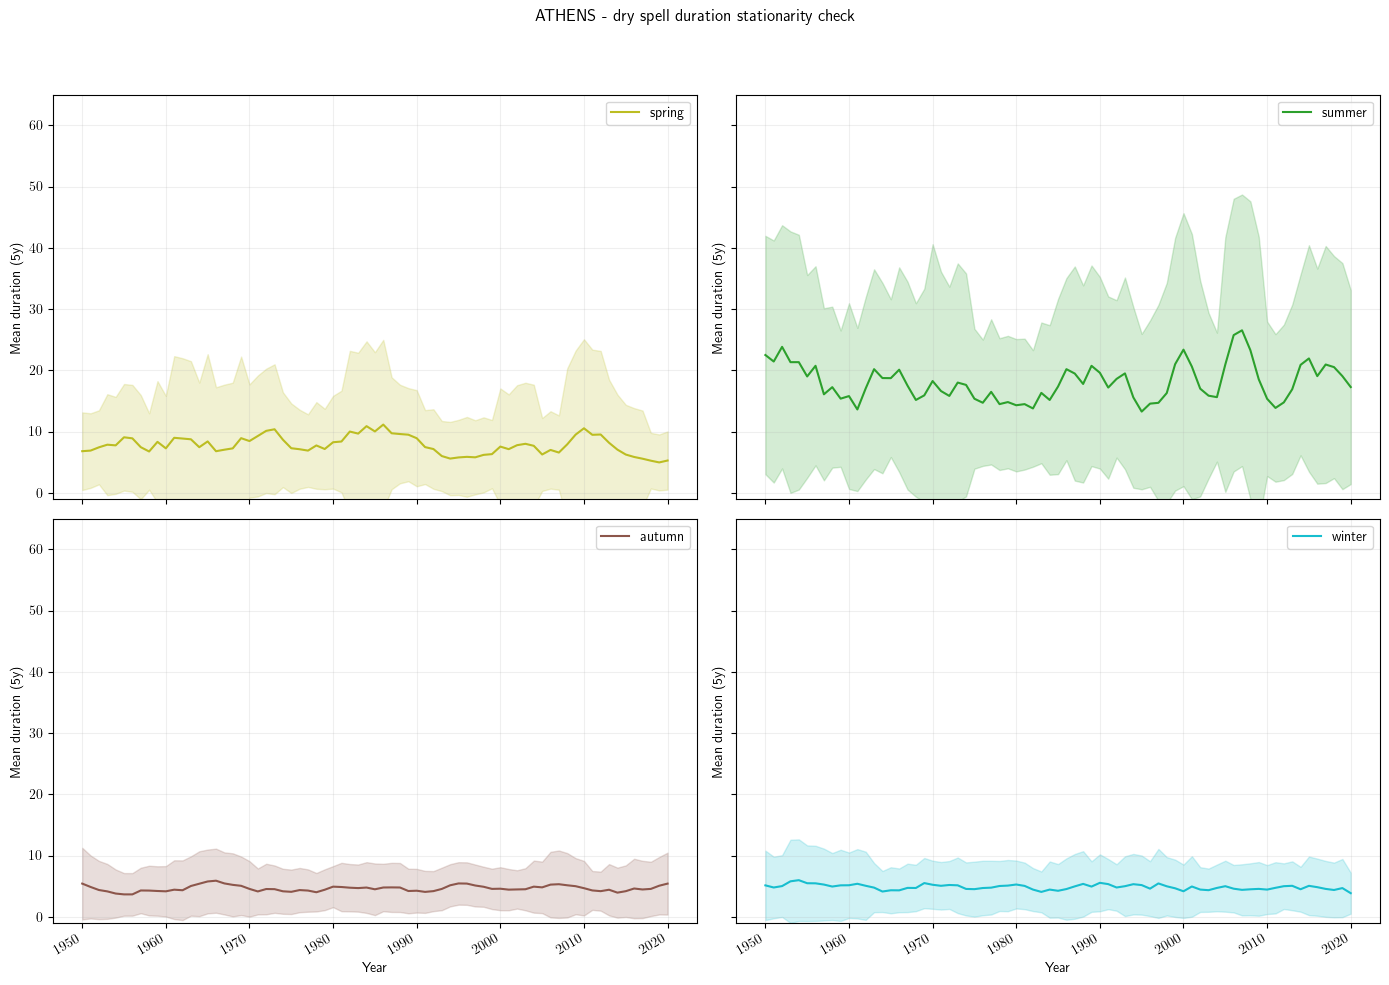

In [5]:
# Inline preview: show the stationarity figure for the first station, dry spell
from IPython.display import IFrame
import matplotlib.pyplot as plt
from article_code.run_all_stations_stationarity import make_stationarity_figure

preview_station = sorted(spells.keys())[0]
fig = make_stationarity_figure(preview_station, spells, "dry_spell")
plt.show()
plt.close(fig)

## 5. Per-station diagnostic figures (Figs 2, 6-11)

Seven PDFs per station: survival overlay, bivariate ACF, dry/wet histograms with fitted pmf, dry/wet Q-Q plots, exit-probability curve.

In [6]:
figure_results = runner.run_per_station_figures(
    spells, df_fit_dry, df_fit_wet, paths["figures_root"],
    only=ONLY, first=FIRST, skip_existing=SKIP_EXISTING,
)
fail = {s: v for s, v in figure_results.items()
        if any(str(x).startswith("FAIL") for x in v.values())}
print(f"[figures] {len(figure_results)} stations, {len(fail)} with failures")
if fail:
    for s, v in list(fail.items())[:5]:
        print(f"  {s}: {v}")

[figures] 5 station(s) -> C:\Users\antoi\Desktop\code\companion_code_article\figures\toy/figure_*/


100%|██████████| 5/5 [01:34<00:00, 18.86s/it]

[figures] 5 stations, 0 with failures


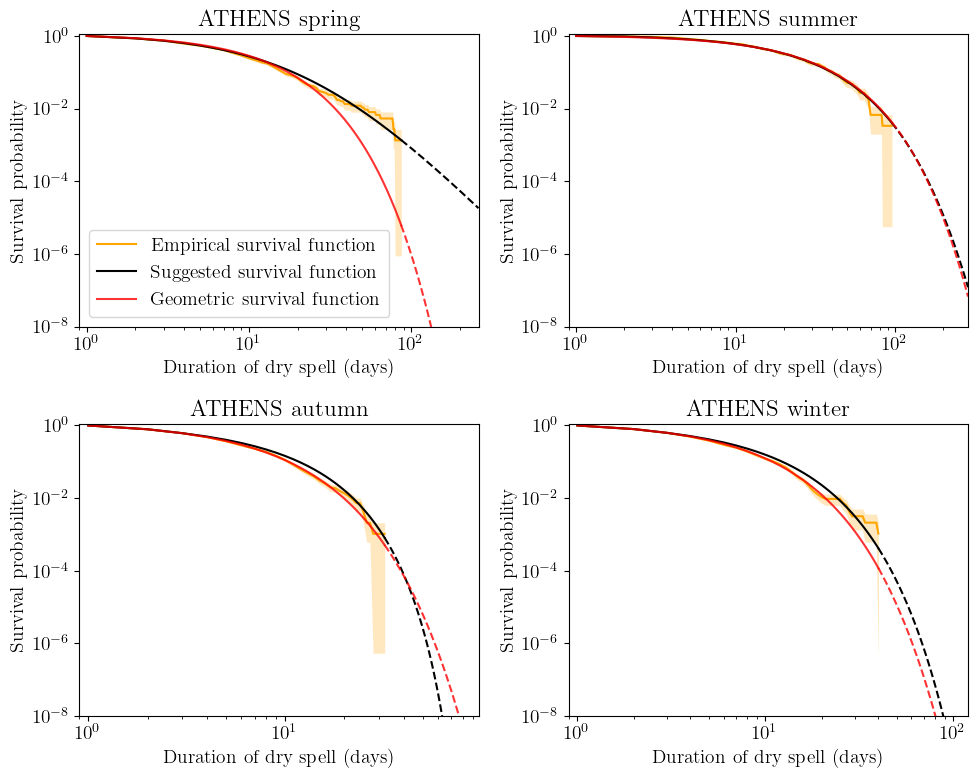

In [7]:
# Inline preview: Fig 2 (survival overlay) for the first station
from article_code.run_all_stations_figures import make_fig2_survival_overlay

preview_station = sorted(spells.keys())[0]
fig = make_fig2_survival_overlay(preview_station, spells, df_fit_dry)
plt.show()
plt.close(fig)

## 6. Output summary

In [8]:
for k, v in paths.items():
    exists = v.exists() if hasattr(v, "exists") else False
    print(f"{k:18s} {'[ok]' if exists else '[ -- ]'}  {v}")

root               [ok]  C:\Users\antoi\Desktop\code\companion_code_article
spells_json        [ok]  C:\Users\antoi\Desktop\code\companion_code_article\data\toy_data\exports_json\toy_spells.json
fit_folder         [ok]  C:\Users\antoi\Desktop\code\companion_code_article\results_fit\fit_toy
dry_fit_csv        [ok]  C:\Users\antoi\Desktop\code\companion_code_article\results_fit\fit_toy\dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv
wet_fit_csv        [ok]  C:\Users\antoi\Desktop\code\companion_code_article\results_fit\fit_toy\wet_spell_fit_mixt_geomresult_fit_parameters.csv
stationarity_dir   [ok]  C:\Users\antoi\Desktop\code\companion_code_article\figures\toy\stationnarity
figures_root       [ok]  C:\Users\antoi\Desktop\code\companion_code_article\figures\toy
